<a href="https://colab.research.google.com/github/marieee005/EstadisticaVerano2026/blob/main/Problemarios/U4_Copia_de_Problemas_Un_Factor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Analiza los siguientes diseños experimentales, e intenta sacar el máximo valor a la información. Verifica los supuestos (linealidad, homscedasticidad e independencia), puedes apoyarte en [la guía de la unidad 4](https://github.com/DrFaus/Estadistica2026B/blob/main/DiseniosExperimentalesUnFactor.ipynb). Aplica una prueba post-hoc en caso que sea necesario. Redacta una conclusión y una recomendación para las personas que recolectaron los datos.

1. **Comparación de cuatro métodos de ensamble:** Un equipo de mejora investiga el efecto de cuatro métodos de ensamble A, B, C y D, sobre el tiempo de ensamble en minutos. En primera instancia, la estrategia experimental es aplicar cuatro veces los cuatro métodos de ensamble en orden completamente aleatorio (las 16 pruebas en orden aleatorio). Los tiempos de ensamble obtenidos se muestran en la tabla 3.1. Si se usa el diseño completamente al azar (DCA), se supone que, además del método de ensamble, no existe ningún otro factor que influya de manera significativa sobre la variable de respuesta (tiempo de ensamble).

| Método de ensamble | A  | B  | C  | D  |
|--------------------|----|----|----|----|
|                    | 6  | 7  | 11 | 10 |
|                    | 8  | 9  | 16 | 12 |
|                    | 7  | 10 | 11 | 11 |
|                    | 8  | 8  | 13 | 9  |


In [ ]:
# Marielena Carvajal Becerra
import pandas as pd
from io import StringIO

datos = '''
metodo,minutos
A,6
B,7
C,11
D,10
A,8
B,9
C,16
D,12
A,7
B,10
C,11
D,11
A,8
B,8
C,13
D,9
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,metodo,minutos
0,A,6
1,B,7
2,C,11
3,D,10
4,A,8
5,B,9
6,C,16
7,D,12
8,A,7
9,B,10


In [ ]:
# Marielena Carvajal Becerra
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('minutos ~ C(metodo)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(metodo),69.5,3.0,9.4237,0.0018
Residual,29.5,12.0,NaN,NaN


In [ ]:
residuales = modelo.resid
# Marielena Carvajal Becerra

valor-p (Shapiro) = 0.2808008139238355


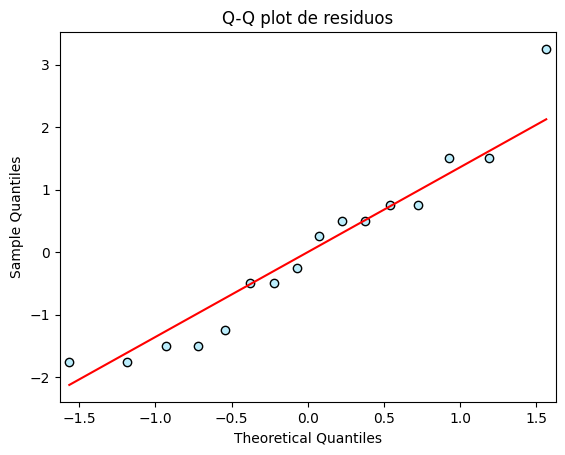

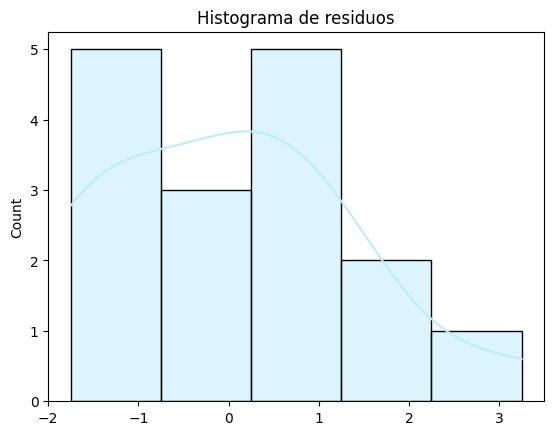

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s',
          markerfacecolor='#BBEDFC',markeredgecolor='black',)
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True,color="#BBEDFC")
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['metodo'] == 'A']['minutos']
grupo_B = df[df['metodo'] == 'B']['minutos']
grupo_C = df[df['metodo'] == 'C']['minutos']
grupo_D = df[df['metodo'] == 'D']['minutos']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.9474
p-valor: 0.4485


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B     1.25 0.6805 -2.0416 4.5416  False
     A      C      5.5 0.0016  2.2084 8.7916   True
     A      D     3.25 0.0533 -0.0416 6.5416  False
     B      C     4.25  0.011  0.9584 7.5416   True
     B      D      2.0 0.3181 -1.2916 5.2916  False
     C      D    -2.25 0.2309 -5.5416 1.0416  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

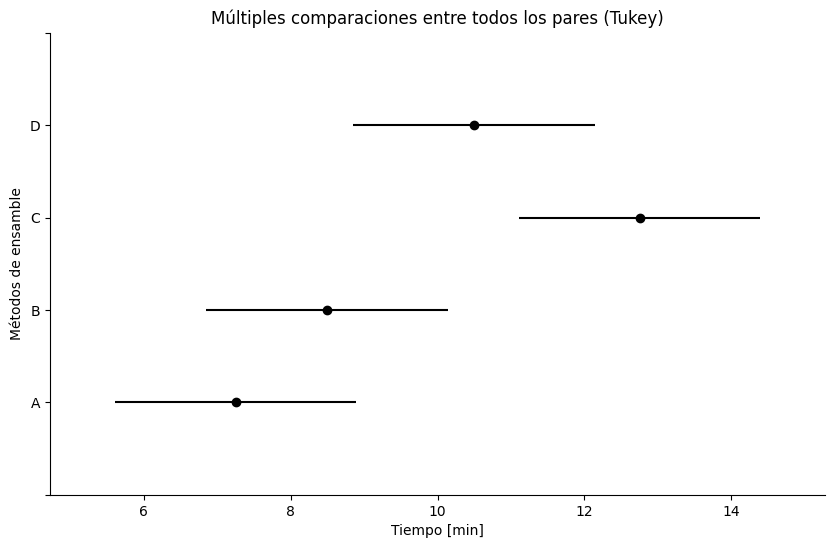

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Marielena Carvajal Becerra

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['minutos'], # Variable de respuesta
    groups=df['metodo'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Métodos de ensamble", xlabel="Tiempo [min]")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método

# Marielena Carvajal Becerra

df.groupby(["metodo"]).mean()["minutos"]

,minutos
metodo,
A,7.25
B,8.50
C,12.75
D,10.50


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

# Marielena Carvajal Becerra

eta_squared = tabla_anova['sum_sq']['C(metodo)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.702


In [ ]:
# Marielena Carvajal Becerra
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["metodo"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.7020
f de Cohen = 1.5349
Potencia de la prueba = 0.9956


In [ ]:
# Marielena Carvajal Becerra
n_necesario = analisis_potencia.solve_power(
    effect_size=f_cohen,
    alpha=0.05,
    power=0.80,   # Potencia de la prueba
    k_groups=k_grupos
)

print(f"Observaciones totales necesarias: {n_necesario:.2f}")
print(f"Observaciones por grupo: {np.ceil(n_necesario / k_grupos):.0f}")

Observaciones totales necesarias: 9.56
Observaciones por grupo: 3


Conclusión:
El diseño experimental es un DCA que cumple con los supuestos de normalidad y homoscedasticidad. Según el test de ANOVA hay diferencia significativa en al menos un método C es el único que muestra una duferencia significativa respecto a los démas. Sin embargo el método C aumenta el tiempo de ensamble, por lo que recomendamos evitarlo y usar en cambio el método A,B o D. Aunque el método A mostró mejores resltados en este experimento, no se encontró una diferencia significativa con los métodos B o D.

El tamaño del efecto es de 0.702, lo que indica que el cambio en los métodos de ensamble justifica en un 70.2% los cambios observados en los tiempos de ensamble. La potencia de la prueba de 0.9956 indica que tenemos un 99.56% de probabilidad de rechazar la hipótesis nula dado que es falsa. Esto le da mucho sustento a los resultados observados.

Si quisieramos trabajar con una potencia de la prueba del 80%, sólo hacían falta 3 observaciones por grupo. Al tener 4, reforzamos las conclusiones del estudio.

2. **Comparación de cuatro tipos de cuero:** Un fabricante de calzado desea mejorar la calidad de las suelas, las cuales se pueden hacer con uno de los cuatro tipos de cuero A, B, C y D disponibles en el mercado. Para ello, prueba los cueros con una máquina que hace pasar los zapatos por una superficie abrasiva; la suela de éstos se desgasta al pasarla por dicha superficie. Como criterio de desgaste se usa la pérdida de peso después de un número fijo de ciclos. Se prueban en orden aleatorio 24 zapatos, seis de cada tipo de cuero. Al hacer las pruebas en orden completamente al azar se evitan sesgos y las mediciones en un tipo de cuero resultan independientes de las demás. Los datos (en miligramos) sobre el desgaste de cada tipo de cuero se muestran en la tabla.

| Tipo de cuero | Observaciones                  | Promedio |
|---------------|--------------------------------|----------|
| A             | 264, 260, 258, 241, 262, 255 | 256.7    |
| B             | 208, 220, 216, 200, 213, 206 | 209.8    |
| C             | 220, 263, 219, 225, 230, 228 | 230.8    |
| D             | 217, 226, 215, 227, 220, 222 | 220.7    |


In [ ]:
# Marielena Carvajal Becerra
import pandas as pd
from io import StringIO

datos = '''
tipo_de_cuero,observaciones
A,264
A,260
A,258
A,241
A,262
A,255
B,208
B,220
B,216
B,200
B,213
B,206
C,220
C,263
C,219
C,225
C,230
C,228
D,217
D,226
D,215
D,227
D,220
D,222
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,tipo_de_cuero,observaciones
0,A,264
1,A,260
2,A,258
3,A,241
4,A,262
5,A,255
6,B,208
7,B,220
8,B,216
9,B,200


In [ ]:
# Marielena Carvajal Becerra
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('observaciones ~ C(tipo_de_cuero)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(tipo_de_cuero),7019.4583,3.0,22.7554,0.0
Residual,2056.5000,20.0,NaN,NaN


In [ ]:
residuales = modelo.resid
# Marielena Carvajal Becerra

valor-p (Shapiro) = 0.00967014513830024


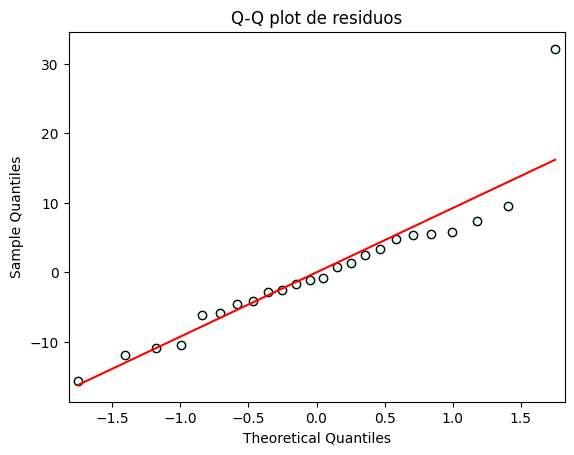

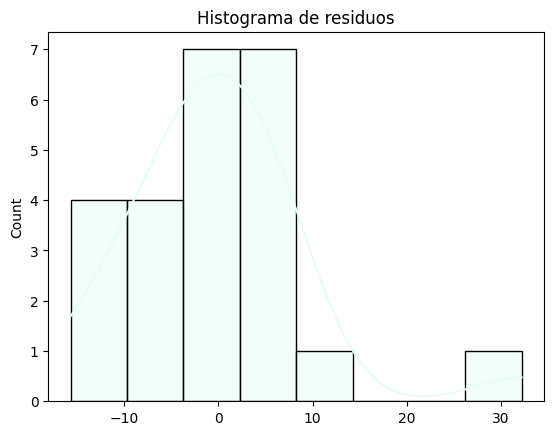

In [ ]:
import statsmodels.api as sm

# Marielena Carvajal Becerra
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s',
          markerfacecolor='#E7FEF5',markeredgecolor='black',)
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True,color="#E7FEF5")
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['tipo_de_cuero'] == 'A']['observaciones']
grupo_B = df[df['tipo_de_cuero'] == 'B']['observaciones']
grupo_C = df[df['tipo_de_cuero'] == 'C']['observaciones']
grupo_D = df[df['tipo_de_cuero'] == 'D']['observaciones']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.5797
p-valor: 0.6351


Lambda óptimo: -3.707788382033557


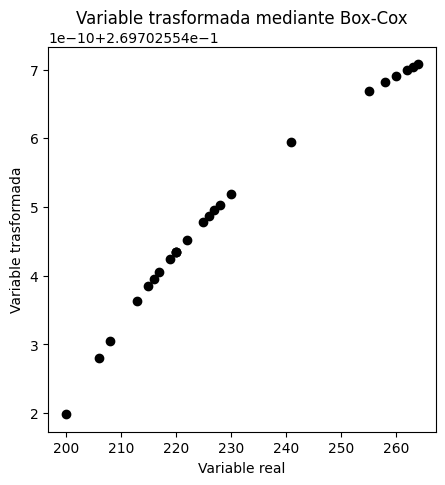

In [ ]:
# Marielena Carvajal Becerra
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["observaciones_boxcox"], lambda_opt = boxcox(df["observaciones"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["observaciones"], df["observaciones_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [ ]:
# Marielena Carvajal Becerra
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('observaciones_boxcox~ C(tipo_de_cuero)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(tipo_de_cuero),0.0,3.0,23.3682,0.0
Residual,0.0,20.0,NaN,NaN


In [ ]:
residuales = modelo.resid
# Marielena Carvajal Becerra

valor-p (Shapiro) = 0.4576953738713335


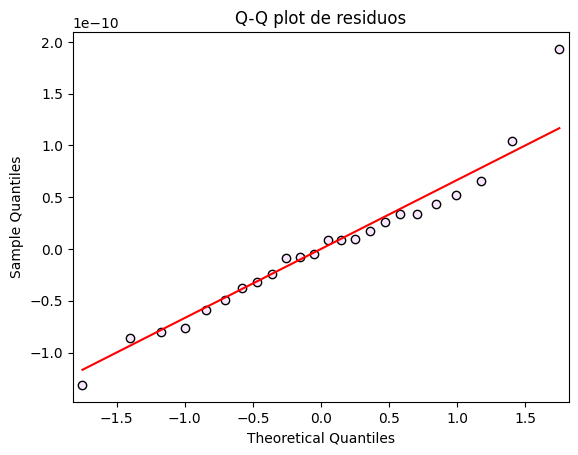

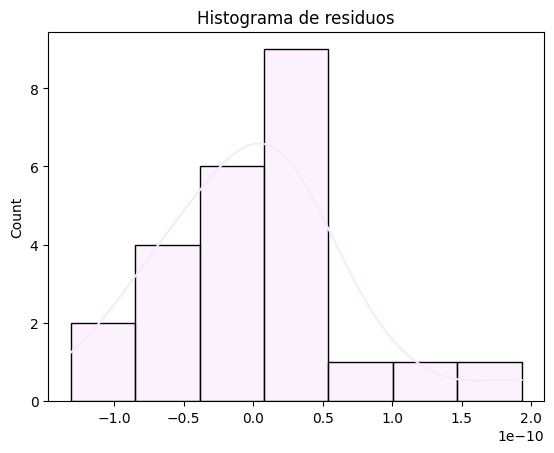

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s',
          markerfacecolor='#F9E7FE',markeredgecolor='black',)
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True,color="#F9E7FE")
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['tipo_de_cuero'] == 'A']['observaciones_boxcox']
grupo_B = df[df['tipo_de_cuero'] == 'B']['observaciones_boxcox']
grupo_C = df[df['tipo_de_cuero'] == 'C']['observaciones_boxcox']
grupo_D = df[df['tipo_de_cuero'] == 'D']['observaciones_boxcox']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 1.1788
p-valor: 0.3428


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower upper reject
------------------------------------------------
     A      B     -0.0    0.0  -0.0  -0.0   True
     A      C     -0.0 0.0048  -0.0  -0.0   True
     A      D     -0.0 0.0001  -0.0  -0.0   True
     B      C      0.0 0.0018   0.0   0.0   True
     B      D      0.0 0.0613  -0.0   0.0  False
     C      D     -0.0  0.401  -0.0   0.0  False
------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

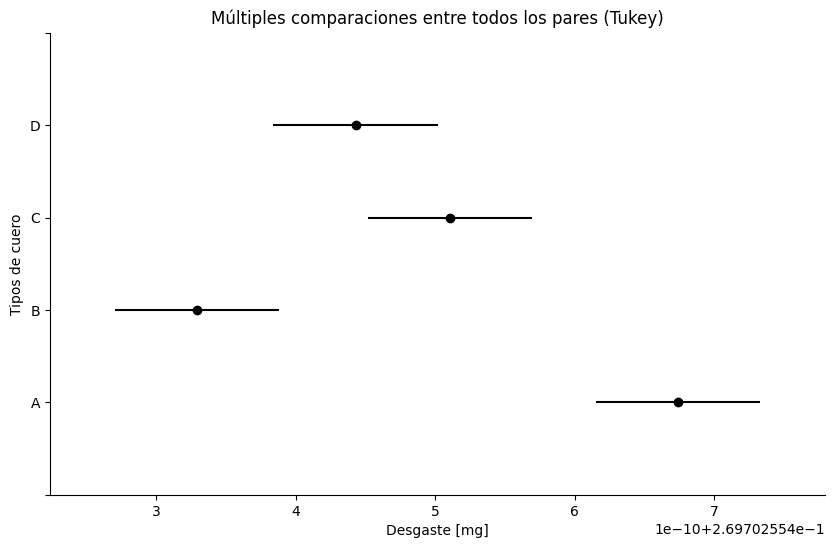

In [ ]:
# Marielena Carvajal Becerra
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['observaciones_boxcox'], # Variable de respuesta
    groups=df['tipo_de_cuero'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Tipos de cuero", xlabel="Desgaste [mg]")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

Conclusión:

Al inicio no se cumplió con el supuesto de normalidad, ya que salio un valor p de 0.0097 en la prueba de Shapiro-Wilk, por esa razón se aplica una transformación Box-Cox, para que después de la aplicación se cumpla la normalidad con un valor p de 0.4577 y la homocesdasticidad con 0.3428.

El ANOVA indica que tipo de cuero produce diferencias en el desgaste. El cuero **A** tuvo un mayor promedio y el cuero **B** tiene el menor promedio. En la prueba de Tukey se mostro qué **B** y **D** no son significativamente difernetes entre sí.

Por lo que se recomienda utilizar el cuero **B**, ya que esta presentó el menor desgaste. Aunque el cuero **D** también se puede considerar como una alternativa ya que tuvo un desgate similar al cuero **B**.

3. En un centro de investigación se realiza un estudio para comparar varios tratamientos que, al aplicarse previamente a los frijoles crudos, reducen su tiempo de cocción. Estos tratamientos son a base de bicarbonato de sodio y cloruro de sodio o sal común. El primer tratamiento ($T_1$) es el de control, que consiste en no aplicar ningún tratamiento. El tratamiento $T_2$ es el remojo en agua con bicarbonato de sodio, el $T_3$ es remojar en agua con sal común y el $T_4$ es remojar en agua con una combinación de ambos ingredientes en proporciones iguales. La variable de respuesta es el tiempo de cocción en minutos. Los datos se muestran en la siguiente tabla:

| $T_1$ | $T_2$  | $T_3$  | $T_4$  |
|---------|-----|-----|-----|
| 213     | 76  | 57  | 84  |
| 214     | 85  | 67  | 82  |
| 204     | 74  | 55  | 85  |
| 208     | 78  | 64  | 92  |
| 212     | 82  | 61  | 87  |
| 200     | 75  | 63  | 79  |
| 207     | 82  | 63  | 90  |



In [ ]:
# Marielena Carvajal Becerra
import pandas as pd
from io import StringIO

datos = '''
Tratamiento,Minutos
T1,213
T2,76
T3,57
T4,84
T1,214
T2,85
T3,67
T4,82
T1,204
T2,74
T3,55
T4,85
T1,208
T2,78
T3,64
T4,92
T1,212
T2,82
T3,61
T4,87
T1,200
T2,75
T3,63
T4,79
T1,207
T2,82
T3,63
T4,90
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df


,Tratamiento,Minutos
0,T1,213
1,T2,76
2,T3,57
3,T4,84
4,T1,214
5,T2,85
6,T3,67
7,T4,82
8,T1,204
9,T2,74


In [ ]:
# Marielena Carvajal Becerra
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('Minutos ~ C(Tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tratamiento),95041.2500,3.0,1558.966,0.0
Residual,487.7143,24.0,NaN,NaN


In [ ]:
residuales = modelo.resid
# Marielena Carvajal Becerra

valor-p (Shapiro) = 0.34689165649615683


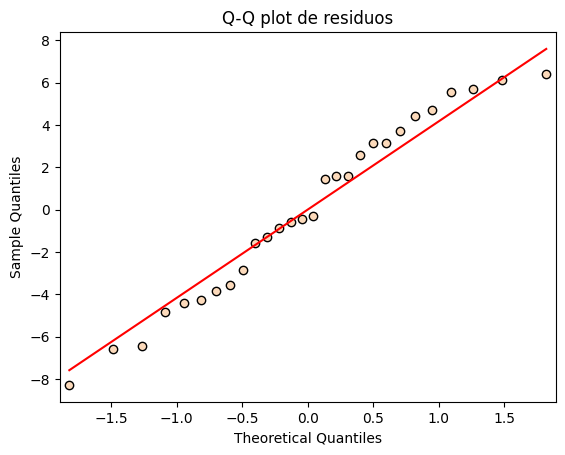

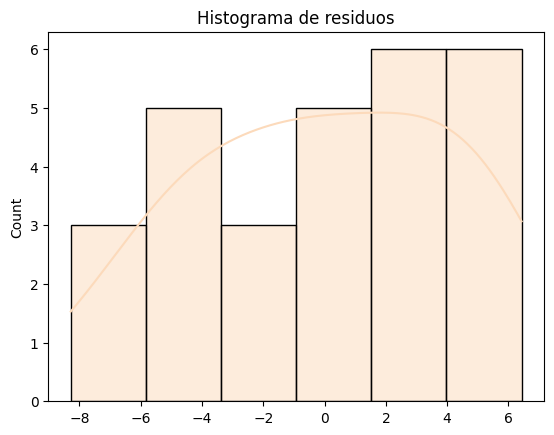

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s',
          markerfacecolor='#FCDABB',markeredgecolor='black',)
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True,color="#FCDABB")
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['Tratamiento'] == 'T1']['Minutos']
grupo_B = df[df['Tratamiento'] == 'T2']['Minutos']
grupo_C = df[df['Tratamiento'] == 'T3']['Minutos']
grupo_D = df[df['Tratamiento'] == 'T4']['Minutos']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.1631
p-valor: 0.9201


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
    T1     T2 -129.4286    0.0 -136.0757 -122.7815   True
    T1     T3 -146.8571    0.0 -153.5043   -140.21   True
    T1     T4 -122.7143    0.0 -129.3614 -116.0672   True
    T2     T3  -17.4286    0.0  -24.0757  -10.7815   True
    T2     T4    6.7143 0.0471    0.0672   13.3614   True
    T3     T4   24.1429    0.0   17.4957     30.79   True
---------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

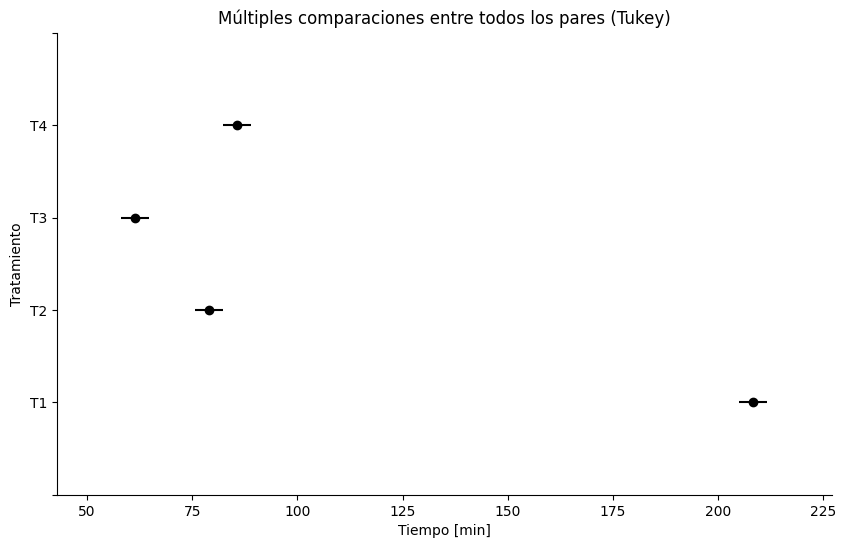

In [ ]:
# Marielena Carvajal Becerra
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Minutos'], # Variable de respuesta
    groups=df['Tratamiento'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Tratamiento", xlabel="Tiempo [min]")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Marielena Carvajal Becerra
# Calcular promedios de cada método

df.groupby(["Tratamiento"]).mean()["Minutos"]

,Minutos
Tratamiento,
T1,208.285714
T2,78.857143
T3,61.428571
T4,85.571429


In [ ]:
# Marielena Carvajal Becerra
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(Tratamiento)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.995


In [ ]:
# Marielena Carvajal Becerra
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["Tratamiento"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9949
f de Cohen = 13.9596
Potencia de la prueba = 1.0000


Conclusión:

En la prueba de Shapiro-Wilk se ontuvo un valor-p de 0.3468, por lo que si cumple con la normalidad y en la prueba Levene se obtuvo un valor-p de 0.9201, que igual se cumple con la homoscedasticidad.

El ANOVA muestra diferencias significativas en los cuatro tratamientos, en la prueba de Tukey se ve que los tratamientos son diferentees entre sí. El **T3** prensenta el menor tiempo de cocción con 61.42 minutos, mientras **T1** tuvo el mayor con 208.28 minutos, por lo que se recomienda usar el Tratamiento **T3**.

El tamaño del efecto es de 0.9949 que es el 99.49% de los cambios en el tiempo de cocción y la potencia es de 1.00000, lo que indica que la prueba tuvo una capacidad alta para detectar las diferencias.

4. Para estudiar la confiabilidad de ciertos tableros electrónicos para carros, se someten a un envejecimiento acelerado durante 100 horas a determinada temperatura, y como variable de interés se mide la intensidad de corriente que circula entre dos puntos, cuyos valores aumentan con el deterioro. Se probaron 20 módulos repartidos de manera equitativa en cinco temperaturas y los resultados obtenidos fueron los siguientes:

| 20°C | 40°C | 60°C | 80°C | 100°C |
|------|------|------|------|-------|
| 15   | 17   | 23   | 28   | 45    |
| 18   | 21   | 19   | 32   | 51    |
| 13   | 11   | 25   | 34   | 57    |
| 12   | 16   | 22   | 31   | 48    |


In [ ]:
# Marielena Carvajal Becerra
import pandas as pd
from io import StringIO

datos = '''
Temperatura,Intensidad
20,15
20,18
20,13
20,12
40,17
40,21
40,11
40,16
60,23
60,19
60,25
60,22
80,28
80,32
80,34
80,31
100,45
100,51
100,57
100,48
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Temperatura,Intensidad
0,20,15
1,20,18
2,20,13
3,20,12
4,40,17
5,40,21
6,40,11
7,40,16
8,60,23
9,60,19


In [ ]:
# Marielena Carvajal Becerra
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('Intensidad ~ C(Temperatura)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Temperatura),3411.8,4.0,68.0545,0.0
Residual,188.0,15.0,NaN,NaN


In [ ]:
residuales = modelo.resid
# Marielena Carvajal Becerra

valor-p (Shapiro) = 0.7785351257478148


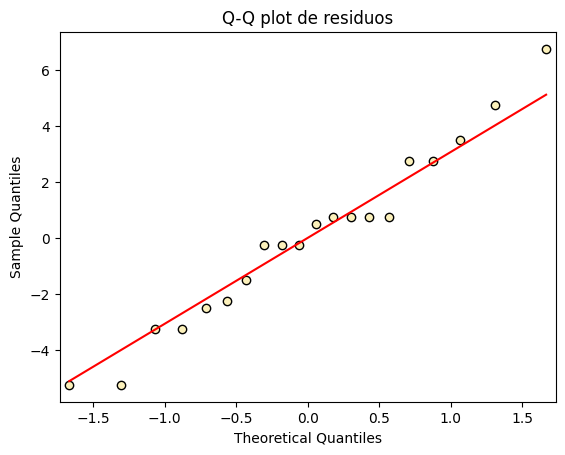

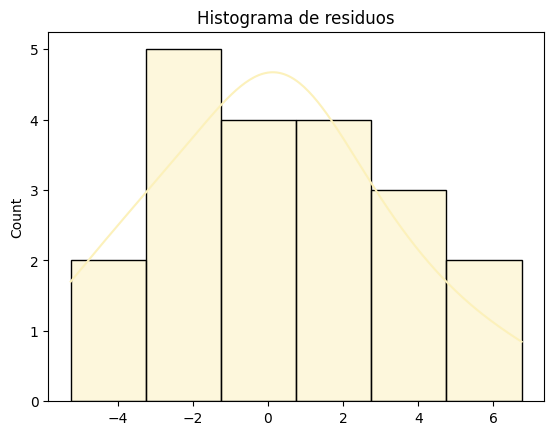

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s',
          markerfacecolor='#FCF1BB',markeredgecolor='black',)
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True,color="#FCF1BB")
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import levene

# Separar por grupos

grupo_A = df[df['Temperatura'] == 20]['Intensidad']
grupo_B = df[df['Temperatura'] == 40]['Intensidad']
grupo_C = df[df['Temperatura'] == 60]['Intensidad']
grupo_D = df[df['Temperatura'] == 80]['Intensidad']
grupo_E = df[df['Temperatura'] == 100]['Intensidad']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D, grupo_E)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.6808
p-valor: 0.6160


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    20     40     1.75 0.9535 -5.9801  9.4801  False
    20     60     7.75 0.0493  0.0199 15.4801   True
    20     80    16.75 0.0001  9.0199 24.4801   True
    20    100    35.75    0.0 28.0199 43.4801   True
    40     60      6.0 0.1696 -1.7301 13.7301  False
    40     80     15.0 0.0002  7.2699 22.7301   True
    40    100     34.0    0.0 26.2699 41.7301   True
    60     80      9.0 0.0191  1.2699 16.7301   True
    60    100     28.0    0.0 20.2699 35.7301   True
    80    100     19.0    0.0 11.2699 26.7301   True
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

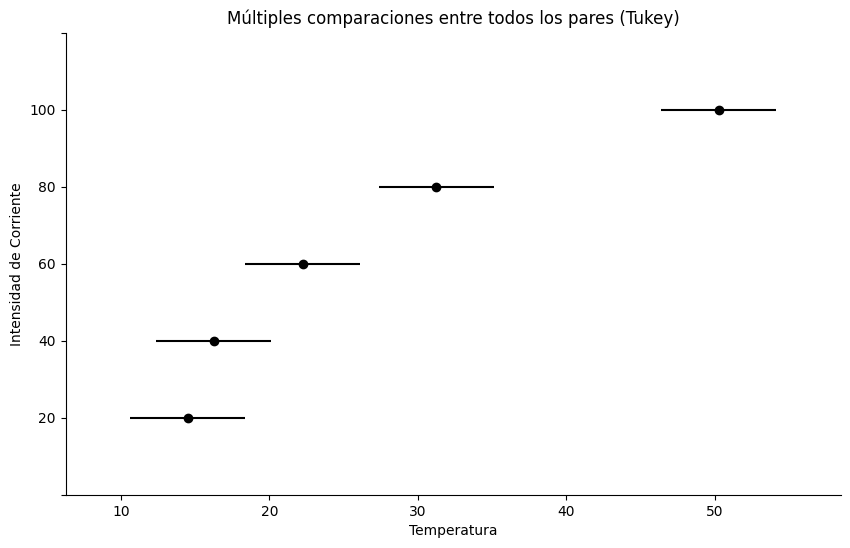

In [ ]:
# Marielena Carvajal Becerra
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Intensidad'], # Variable de respuesta
    groups=df['Temperatura'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Intensidad de Corriente", xlabel="Temperatura")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Marielena Carvajal Becerra
# Calcular promedios de cada método

df.groupby(["Temperatura"]).mean()["Intensidad"]

,Intensidad
Temperatura,
20,14.50
40,16.25
60,22.25
80,31.25
100,50.25


In [ ]:
# Marielena Carvajal Becerra
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(Temperatura)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.948


In [ ]:
# Marielena Carvajal Becerra
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["Temperatura"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9478
f de Cohen = 4.2600
Potencia de la prueba = 1.0000


Conclusión:

En este ejercicio se cumple con la normalidad y homoscedasticidad, ya que en la prueba de Shapiro-Wilk se obtuvo un valor de 0.7785 y en la homoscedasticidad se tiene un valor-p 0.6160, como ambos son mayores a 0.05 se aprueban.

En el ANOVA las diferencias son significaticas entre las temperaturas. Hubo un aumento de 14.50 a **20°C** hasta 50.25 a **100°C**. En la prueba de Tukey no se encuentra diferencia significativa entre **20°C** y **40°C**, pero si hay diferencia entre las temperaturas más bajas y las más altas.

Por lo que se recomienda trabajar a 20°C o 40°C ya que son los niveles más bajos en intensidad. El tamaño del efecto es de 0.9478 que es el 94.78% de los cambios de temperatura observado y como la potencia es de 1.0000 se justifica los resultados.


5. En una empresa de manufactura se propone un tratamiento para reducir el porcentaje de productos defectuosos. Para validar esta propuesta se diseñó un experimento en el que se producía con o sin la propuesta de mejora. Cada corrida experimental consistió en producir un lote y la variable de respuesta es el porcentaje de producto defectuoso. Se hicieron 25 réplicas para cada tratamiento. Los datos obtenidos se muestran a continuación:

| Tratamiento     | Porcentaje de producto defectuoso                                     |
|-----------------|----------------------------------------------------------------------|
| Con tratam.     | 5.3, 4.0, 4.0, 4.0, 2.6, 2.1, 5.1, 4.1, 4.1, 3.2, 5.1, 2.2, 4.1     |
| Sin tratam.     | 8.0, 13.2, 7.2, 8.2, 9.1, 6.7, 12.6, 16.3, 9.2, 6.4, 7.2, 17.2, 12.3 |


In [ ]:
# Marielena Carvajal Becerra
import pandas as pd
from io import StringIO

datos = '''
Tratamiento,Porcentaje
Con tratam.,5.3
Con tratam.,4.0
Con tratam.,4.0
Con tratam.,4.0
Con tratam.,2.6
Con tratam.,2.1
Con tratam.,5.1
Con tratam.,4.1
Con tratam.,4.1
Con tratam.,3.2
Con tratam.,5.1
Con tratam.,2.2
Con tratam.,4.1
Sin tratam.,8.0
Sin tratam.,13.2
Sin tratam.,7.2
Sin tratam.,8.2
Sin tratam.,9.1
Sin tratam.,6.7
Sin tratam.,12.6
Sin tratam.,16.3
Sin tratam.,9.2
Sin tratam.,6.4
Sin tratam.,7.2
Sin tratam.,17.2
Sin tratam.,12.3
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Tratamiento,Porcentaje
0,Con tratam.,5.3
1,Con tratam.,4.0
2,Con tratam.,4.0
3,Con tratam.,4.0
4,Con tratam.,2.6
5,Con tratam.,2.1
6,Con tratam.,5.1
7,Con tratam.,4.1
8,Con tratam.,4.1
9,Con tratam.,3.2


In [ ]:
# Marielena Carvajal Becerra
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('Porcentaje ~ C(Tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tratamiento),269.4496,1.0,37.1028,0.0
Residual,174.2938,24.0,NaN,NaN


In [ ]:
residuales = modelo.resid
# Marielena Carvajal Becerra

valor-p (Shapiro) = 0.08240142335256262


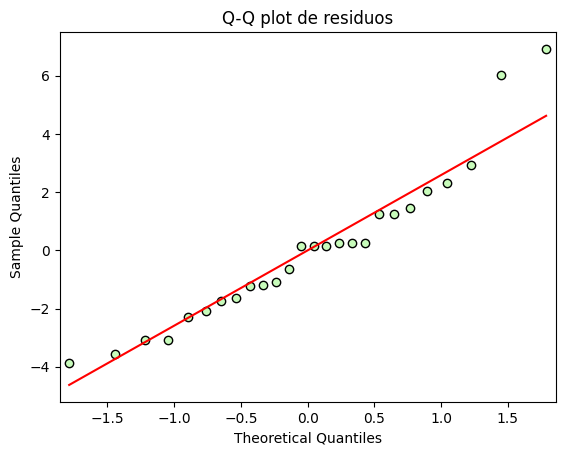

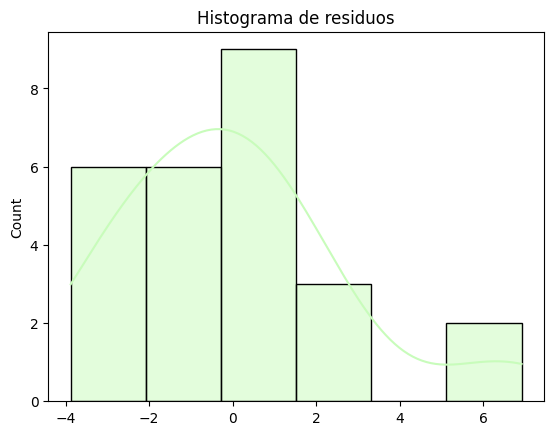

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s',
          markerfacecolor='#C8FCBB',markeredgecolor='black',)
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True,color="#C8FCBB")
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['Tratamiento'] == 'Con tratam.']['Porcentaje']
grupo_B = df[df['Tratamiento'] == 'Sin tratam.']['Porcentaje']

stat, p = levene(grupo_A, grupo_B)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 8.7144
p-valor: 0.0070


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
   group1      group2   meandiff p-adj lower  upper reject
----------------------------------------------------------
Con tratam. Sin tratam.   6.4385   0.0 4.2569  8.62   True
----------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

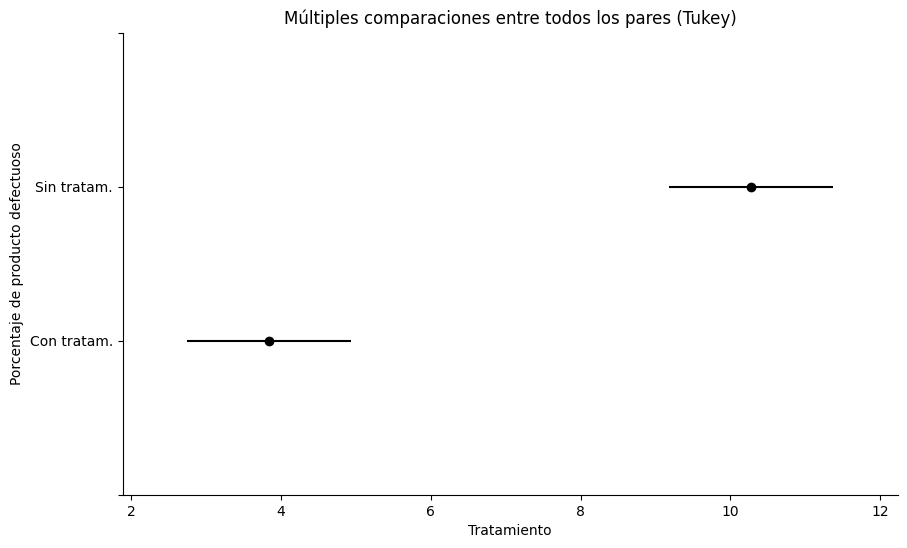

In [ ]:
# Marielena Carvajal Becerra
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Porcentaje'], # Variable de respuesta
    groups=df['Tratamiento'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Porcentaje de producto defectuoso", xlabel="Tratamiento")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Marielena Carvajal Becerra
# Calcular promedios de cada método

df.groupby(["Tratamiento"]).mean()["Porcentaje"]

,Porcentaje
Tratamiento,
Con tratam.,3.838462
Sin tratam.,10.276923


In [ ]:
# Marielena Carvajal Becerra
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(Tratamiento)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.607


In [ ]:
# Marielena Carvajal Becerra
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["Tratamiento"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.6072
f de Cohen = 1.2434
Potencia de la prueba = 1.0000


In [ ]:
# Marielena Carvajal Becerra
n_necesario = analisis_potencia.solve_power(
    effect_size=f_cohen,
    alpha=0.05,
    power=0.80,   # Potencia de la prueba
    k_groups=k_grupos
)

print(f"Observaciones totales necesarias: {n_necesario:.2f}")
print(f"Observaciones por grupo: {np.ceil(n_necesario / k_grupos):.0f}")

Observaciones totales necesarias: 7.57
Observaciones por grupo: 4


Conclusión:

En la prueba Shapiro-Wilk se aprueba la normalidad ya que se obtuvo un valor de 0.0824 y la homoscedasticidad no se aprueba porque se obtuvo un valor-p 0.0070.

En el ANOVA se encuentra diferencia significativa entre los productos con trataminto y sin tratamiento. con el tratamineto se obtuvo un promedio de 3.84% de productos defectuosos, mientras que sin tratamiento el promedio fue de 10.27%, la diferencia promedio entre los dos grupos es de 6.44.

Por lo que el tratamiento ayuda a reducir los productos defectuosos. El tamano del efecto es de 0.6072 y la potencia de 1.0000.

6. Una compañía farmacéutica desea evaluar el efecto que tiene la cantidad de almidón en la dureza de las tabletas. Se decidió producir lotes con una cantidad determinada de almidón, y que las cantidades de almidón a aprobar fueran 2%, 5% y 10%. La variable de respuesta sería el promedio de la dureza de 20 tabletas de cada lote. Se hicieron 4 réplicas por tratamiento y se obtuvieron los siguientes resultados:

| % de almidón | Dureza               |
|--------------|----------------------|
| 2            | 4.3, 5.2, 4.8, 4.5  |
| 5            | 6.5, 7.3, 6.9, 6.1  |
| 10           | 9.0, 7.8, 8.5, 8.1  |


In [ ]:
# Marielena Carvajal Becerra
import pandas as pd
from io import StringIO

datos = '''
Porcentaje_de_almidon,Dureza
2,4.3
2,5.2
2,4.8
2,4.5
5,6.5
5,7.3
5,6.9
5,6.1
10,9.0
10,7.8
10,8.5
10,8.1
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Porcentaje_de_almidon,Dureza
0,2,4.3
1,2,5.2
2,2,4.8
3,2,4.5
4,5,6.5
5,5,7.3
6,5,6.9
7,5,6.1
8,10,9.0
9,10,7.8


In [ ]:
# Marielena Carvajal Becerra
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('Dureza ~ C(Porcentaje_de_almidon)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Porcentaje_de_almidon),26.7267,2.0,58.1014,0.0
Residual,2.0700,9.0,NaN,NaN


In [ ]:
residuales = modelo.resid
# Marielena Carvajal Becerra

valor-p (Shapiro) = 0.42952068080371164


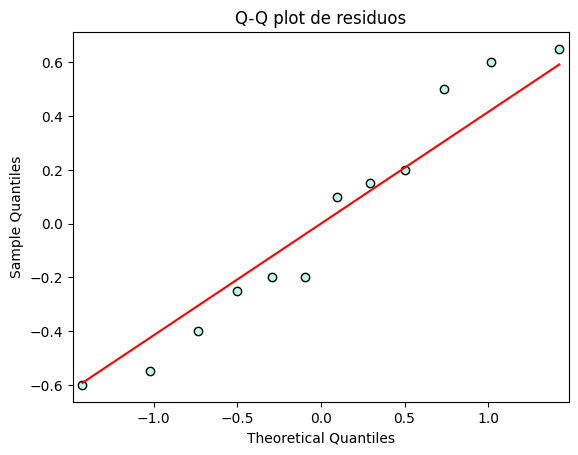

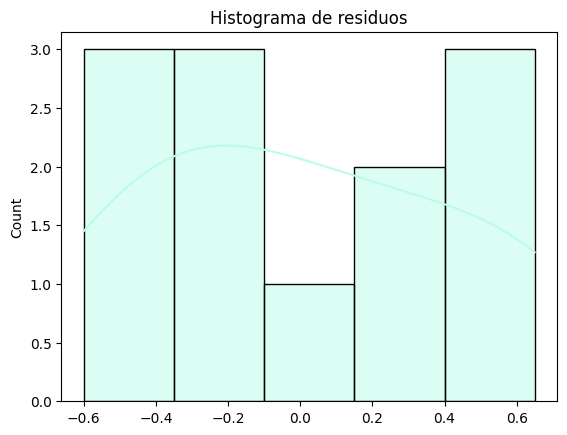

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s',
          markerfacecolor='#BBFCE9',markeredgecolor='black',)
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True,color="#BBFCE9")
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['Porcentaje_de_almidon'] == 2]['Dureza']
grupo_B = df[df['Porcentaje_de_almidon'] == 5]['Dureza']
grupo_C = df[df['Porcentaje_de_almidon'] == 10]['Dureza']

stat, p = levene(grupo_A, grupo_B, grupo_C)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.2667
p-valor: 0.7718


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
     2      5      2.0 0.0006 1.0532 2.9468   True
     2     10     3.65    0.0 2.7032 4.5968   True
     5     10     1.65 0.0023 0.7032 2.5968   True
--------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

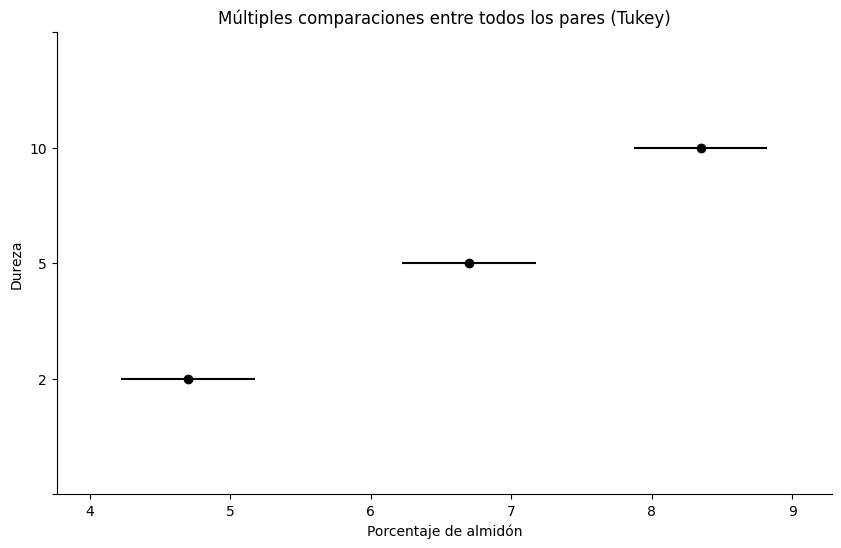

In [ ]:
# Marielena Carvajal Becerra
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Dureza'], # Variable de respuesta
    groups=df['Porcentaje_de_almidon'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Dureza", xlabel="Porcentaje de almidón")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Marielena Carvajal Becerra
# Calcular promedios de cada método

df.groupby(["Porcentaje_de_almidon"]).mean()["Dureza"]

,Dureza
Porcentaje_de_almidon,
2,4.70
5,6.70
10,8.35


In [ ]:
# Marielena Carvajal Becerra
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(Porcentaje_de_almidon)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.928


In [ ]:
# Marielena Carvajal Becerra
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["Porcentaje_de_almidon"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9281
f de Cohen = 3.5932
Potencia de la prueba = 1.0000


Conclusión:

La prueba de Shapiro dio un valor de 0.4295 y la prueba de Levene obtuvo 0.7718. Por eso, se pudo realizar correctamente el ANOVA.

El ANOVA mostró que la cantidad de almidón sí cambia la dureza de las tabletas. Los tres porcentajes fueron diferentes entre sí. El 10 % de almidón tuvo la mayor dureza, con un promedio de 8.35, mientras que el 2 % tuvo un promedio de 4.70.

Por esta razón, se recomienda utilizar 10 % de almidón cuando se quieran obtener tabletas más duras. El tamaño del efecto fue de 0.9281, lo que indica que el almidón explica gran parte de los cambios en la dureza. La potencia fue de 1.0000.

7. Los datos que se presentan enseguida son rendimientos en toneladas por hectárea de un pasto con tres niveles de fertilización nitrogenada. El diseño fue completamente aleatorizado, con cinco repeticiones por tratamiento.

| Niveles de nitrógeno | Rendimientos (ton/ha)       |
|-----------------------|----------------------------|
| 1                     | 14.823, 14.676, 14.720, 14.5141, 15.065 |
| 2                     | 25.151, 25.401, 25.131, 25.031, 25.267 |
| 3                     | 32.605, 32.460, 32.256, 32.669, 32.111 |


In [ ]:
# Marielena Carvajal Becerra
import pandas as pd
from io import StringIO

datos = '''
Niveles_de_nitrógeno,Rendimientos
1,14.823
1,14.676
1,14.720
1,14.5141
1,15.065
2,25.151
2,25.401
2,25.131
2,25.031
2,25.267
3,32.605
3,32.460
3,32.256
3,32.669
3,32.111
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Niveles_de_nitrógeno,Rendimientos
0,1,14.8230
1,1,14.6760
2,1,14.7200
3,1,14.5141
4,1,15.0650
5,2,25.1510
6,2,25.4010
7,2,25.1310
8,2,25.0310
9,2,25.2670


In [ ]:
# Marielena Carvajal Becerra
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('Rendimientos ~ C(Niveles_de_nitrógeno)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Niveles_de_nitrógeno),788.3408,2.0,10131.6193,0.0
Residual,0.4669,12.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.8890610190283172


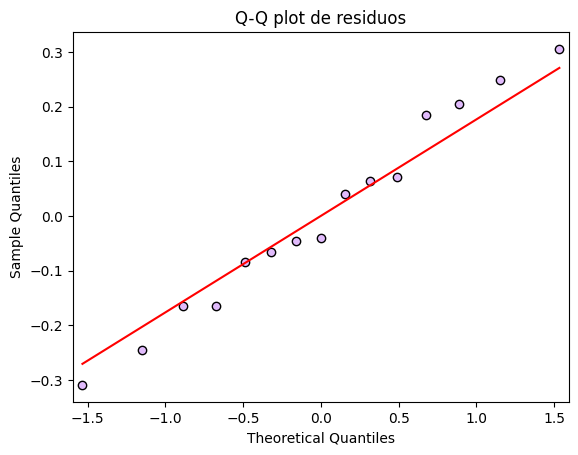

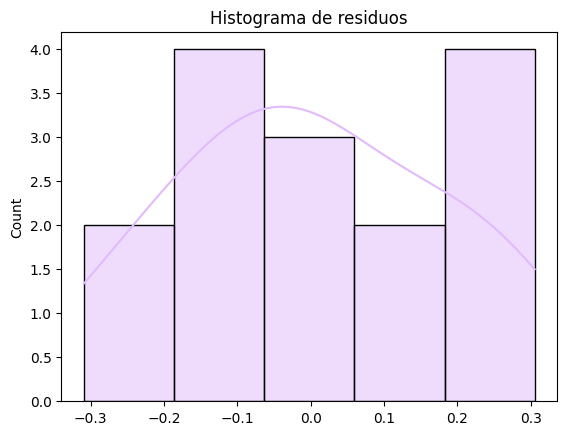

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s',
          markerfacecolor='#E1BBFC',markeredgecolor='black',)
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True,color="#E1BBFC")
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import levene

# Separar por grupo

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['Niveles_de_nitrógeno'] == 1]['Rendimientos']
grupo_B = df[df['Niveles_de_nitrógeno'] == 2]['Rendimientos']
grupo_C = df[df['Niveles_de_nitrógeno'] == 3]['Rendimientos']

stat, p = levene(grupo_A, grupo_B, grupo_C)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.5372
p-valor: 0.5978


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     1      2  10.4366   0.0 10.1038 10.7694   True
     1      3  17.6606   0.0 17.3278 17.9934   True
     2      3    7.224   0.0  6.8912  7.5568   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

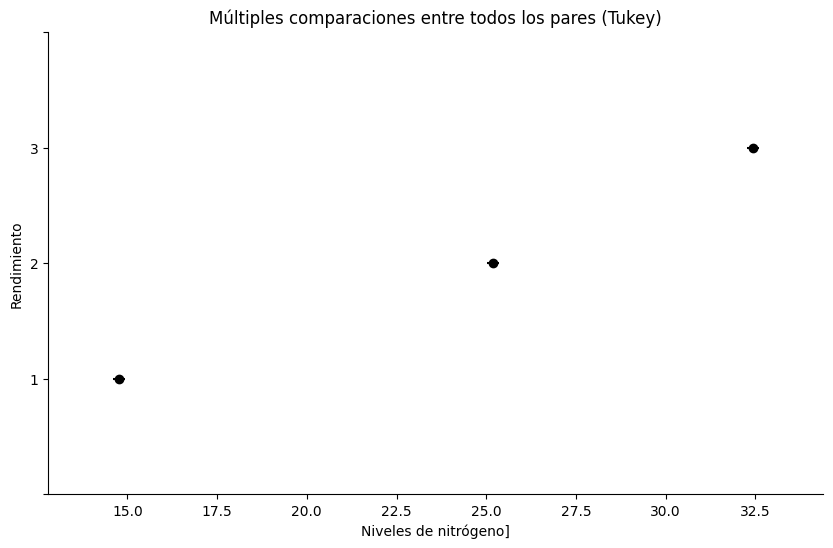

In [ ]:
# Marielena Carvajal Becerra
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Rendimientos'], # Variable de respuesta
    groups=df['Niveles_de_nitrógeno'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Rendimiento", xlabel="Niveles de nitrógeno]")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Marielena Carvajal Becerra
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(Niveles_de_nitrógeno)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.999


In [ ]:
# Marielena Carvajal Becerra
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["Niveles_de_nitrógeno"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9994
f de Cohen = 41.0926
Potencia de la prueba = 1.0000


Conclusión:

En la prueba de Shapiro obtuvo un valor de 0.8891, por lo que los datos tienen una distribución normal. La prueba de Levene dio 0.5978, lo que indica que las varianzas son iguales.

Los resultados del ANOVA muestran que los niveles de nitrógeno sí producen diferentes rendimientos. El nivel 3 presentó el mayor rendimiento, con 32.42 toneladas por hectárea. El nivel 2 obtuvo 25.20 y el nivel 1 solamente 14.76 toneladas por hectárea.

Por lo tanto, se recomienda utilizar el nivel 3 de nitrógeno cuando se quiera conseguir una mayor producción. El tamaño del efecto fue de 0.9994, por lo que casi todos los cambios en el rendimiento se deben al nivel de nitrógeno. La potencia fue de 1.0000.


8. Un químico del departamento de desarrollo de un laboratorio farmacéutico desea conocer cómo influye el tipo de aglutinante utilizado en tabletas de ampicilina de 500 mg en el porcentaje de friabilidad; para ello, se eligen los siguientes aglutinantes: polivinilpirrolidona (PVP), carboximetilcelulosa sódica (CMC) y grenetina (Gre). Los resultados del diseño experimental son los siguientes:

| Aglutinante | % de friabilidad          |
|-------------|---------------------------|
| PVP         | 0.485, 0.250, 0.073, 0.205, 0.161 |
| CMC         | 9.64, 9.37, 9.53, 9.86, 9.79       |
| Gre         | 0.289, 0.275, 0.612, 0.152, 0.137  |


In [ ]:
# Marielena Carvajal Becerra
import pandas as pd
from io import StringIO

datos = '''
Aglutinante,Porcentaje_de_friabilidad
PVP,0.485
PVP,0.250
PVP,0.073
PVP,0.205
PVP,0.161
CMC,9.64
CMC,9.37
CMC,9.53
CMC,9.86
CMC,9.79
Gre,0.289
Gre,0.275
Gre,0.612
Gre,0.152
Gre,0.137
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Aglutinante,Porcentaje_de_friabilidad
0,PVP,0.485
1,PVP,0.250
2,PVP,0.073
3,PVP,0.205
4,PVP,0.161
5,CMC,9.640
6,CMC,9.370
7,CMC,9.530
8,CMC,9.860
9,CMC,9.790


In [ ]:
# Marielena Carvajal Becerra
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('Porcentaje_de_friabilidad ~ C(Aglutinante)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Aglutinante),292.9210,2.0,4420.9726,0.0
Residual,0.3975,12.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.42143454193876007


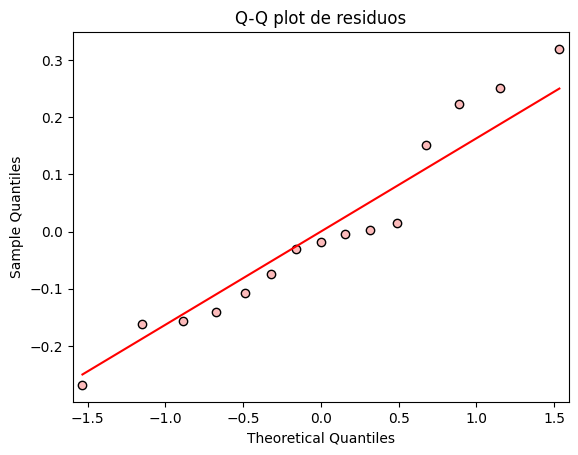

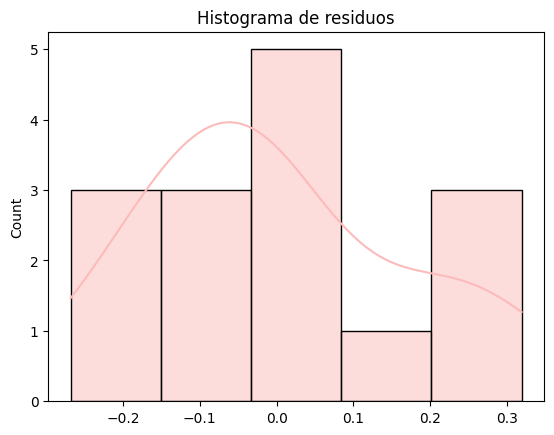

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s',
          markerfacecolor='#FCBBBB',markeredgecolor='black',)
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True,color="#FCBBBB")
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['Aglutinante'] == 'PVP']['Porcentaje_de_friabilidad']
grupo_B = df[df['Aglutinante'] == 'CMC']['Porcentaje_de_friabilidad']
grupo_C = df[df['Aglutinante'] == 'Gre']['Porcentaje_de_friabilidad']

stat, p = levene(grupo_A, grupo_B, grupo_C)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.2250
p-valor: 0.8018


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
   CMC    Gre   -9.345   0.0 -9.6521 -9.0379   True
   CMC    PVP  -9.4032   0.0 -9.7103 -9.0961   True
   Gre    PVP  -0.0582  0.87 -0.3653  0.2489  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

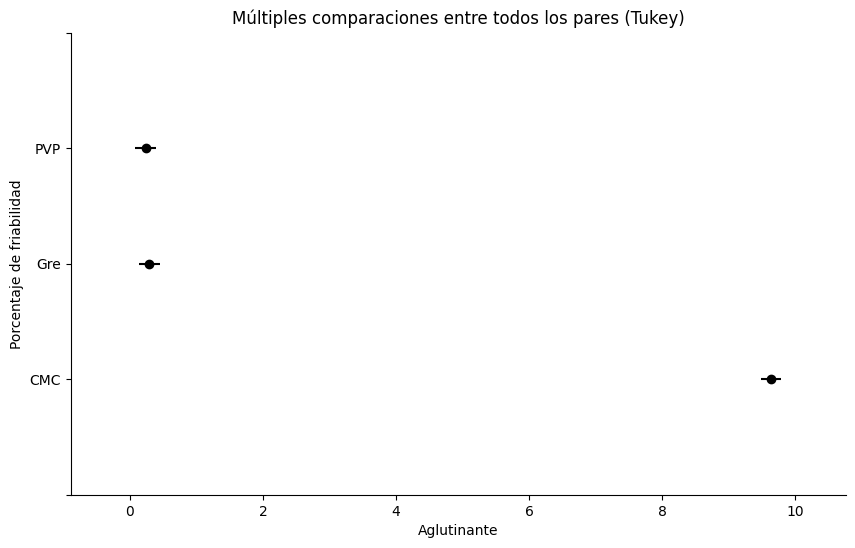

In [ ]:
# Marielena Carvajal Becerra
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Porcentaje_de_friabilidad'], # Variable de respuesta
    groups=df['Aglutinante'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Porcentaje de friabilidad", xlabel="Aglutinante")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Marielena Carvajal Becerra
# Calcular promedios de cada método

df.groupby(["Aglutinante"]).mean()["Porcentaje_de_friabilidad"]

,Porcentaje_de_friabilidad
Aglutinante,
CMC,9.6380
Gre,0.2930
PVP,0.2348


In [ ]:
# Marielena Carvajal Becerra
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(Aglutinante)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.999


In [ ]:
# Marielena Carvajal Becerra
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["Aglutinante"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9986
f de Cohen = 27.1446
Potencia de la prueba = 1.0000


Conclusión:

La prueba de Shapiro tuvo un valor de 0.4214 y la prueba de Levene dio 0.8018. Esto quiere decir que fue correcto realizar el ANOVA.

Los resultados muestran que el tipo de aglutinante sí cambia el porcentaje de friabilidad. La CMC tuvo el porcentaje más alto, con 9.638 %. La grenetina obtuvo 0.293 % y el PVP presentó el porcentaje más bajo, con 0.2348 %. No hubo una diferencia significativa entre PVP y grenetina.

Por eso, se recomienda utilizar PVP o grenetina y evitar la CMC. El PVP sería la mejor opción porque tuvo el promedio más bajo. El tamaño del efecto fue de 0.9986 y la potencia fue de 1.0000, por lo que los resultados tienen un respaldo muy alto.

9. Se cultivaron cuatro diferentes clonas de *agave tequilana* bajo un mismo esquema de manejo. Se quiere saber qué clona es la que responde mejor a dicho manejo, evaluando el nivel de respuesta con el porcentaje de azúcares reductores totales en base húmeda. Los datos se muestran a continuación:

| Clona | Porcentaje de azúcares reductores totales |
|-------|------------------------------------------|
| 1     | 8.69, 6.68, 6.83, 6.43, 10.30            |
| 2     | 8.00, 16.41, 12.43, 10.99, 15.53         |
| 3     | 17.39, 13.73, 15.62, 17.05, 15.42        |
| 4     | 10.37, 9.16, 8.83, 4.40, 10.38           |


In [ ]:
# Marielena Carvajal Becerra
import pandas as pd
from io import StringIO

datos = '''
Clona,Porcentaje_de_azúcares
1,8.69
1,6.68
1,6.83
1,6.43
1,10.30
2,8.00
2,16.41
2,12.43
2,10.99
2,15.53
3,17.39
3,13.73
3,15.62
3,17.05
3,15.42
4,10.37
4,9.16
4,8.83
4,4.40
4,10.38
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Clona,Porcentaje_de_azúcares
0,1,8.69
1,1,6.68
2,1,6.83
3,1,6.43
4,1,10.30
5,2,8.00
6,2,16.41
7,2,12.43
8,2,10.99
9,2,15.53


In [ ]:
# Marielena Carvajal Becerra
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3 = mu_4
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('Porcentaje_de_azúcares ~ C(Clona)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4)

,sum_sq,df,F,PR(>F)
C(Clona),209.9072,3.0,12.3271,0.0002
Residual,90.8168,16.0,NaN,NaN


In [ ]:
residuales = modelo.resid
# Marielena Carvajal Becerra

valor-p (Shapiro) = 0.7677173153296


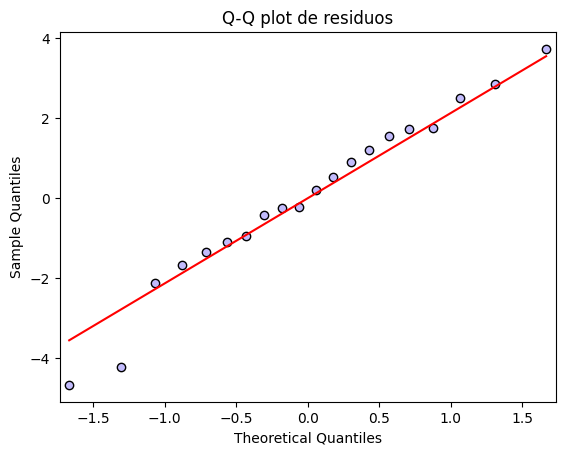

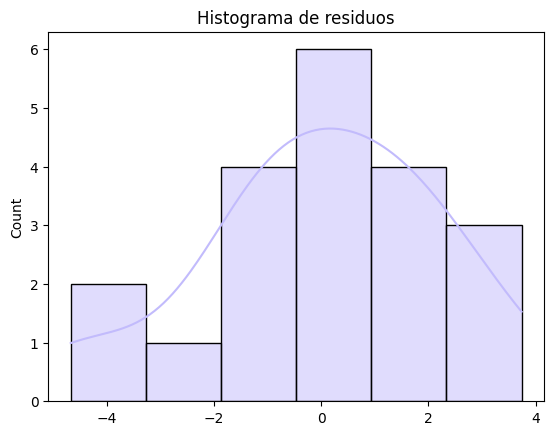

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s',
          markerfacecolor='#C2BBFC',markeredgecolor='black',)
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True,color="#C2BBFC")
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['Clona'] == 1]['Porcentaje_de_azúcares']
grupo_B = df[df['Clona'] == 2]['Porcentaje_de_azúcares']
grupo_C = df[df['Clona'] == 3]['Porcentaje_de_azúcares']
grupo_D = df[df['Clona'] == 4]['Porcentaje_de_azúcares']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.9749
p-valor: 0.4290


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2    4.886 0.0237   0.575  9.197   True
     1      3    8.056 0.0003   3.745 12.367   True
     1      4    0.842 0.9428  -3.469  5.153  False
     2      3     3.17 0.1939  -1.141  7.481  False
     2      4   -4.044 0.0699  -8.355  0.267  False
     3      4   -7.214  0.001 -11.525 -2.903   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

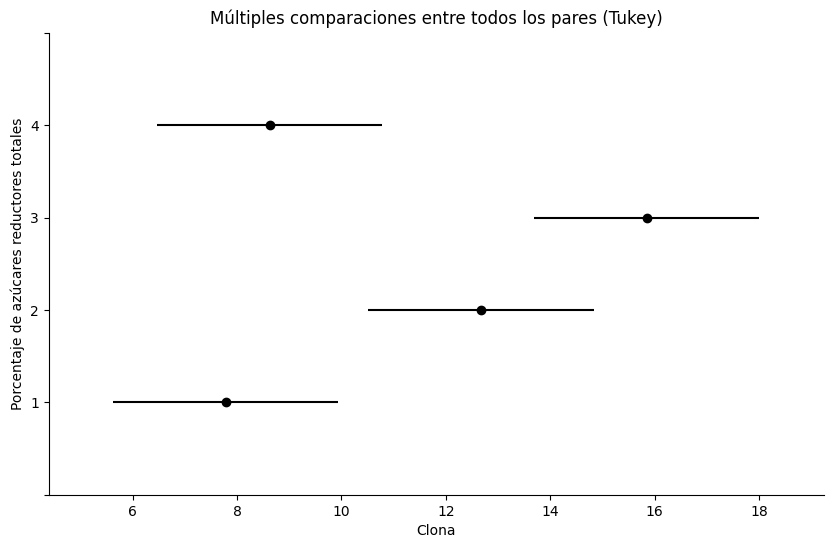

In [ ]:
# Marielena Carvajal Becerra
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Porcentaje_de_azúcares'], # Variable de respuesta
    groups=df['Clona'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Porcentaje de azúcares reductores totales", xlabel="Clona")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Marielena Carvajal Becerra
# Calcular promedios de cada método

df.groupby(["Clona"]).mean()["Porcentaje_de_azúcares"]

,Porcentaje_de_azúcares
Clona,
1,7.786
2,12.672
3,15.842
4,8.628


In [ ]:
# Marielena Carvajal Becerra
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(Clona)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.698


In [ ]:
# Marielena Carvajal Becerra
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["Clona"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.6980
f de Cohen = 1.5203
Potencia de la prueba = 0.9997


In [ ]:
# Marielena Carvajal Becerra
n_necesario = analisis_potencia.solve_power(
    effect_size=f_cohen,
    alpha=0.05,
    power=0.80,   # Potencia de la prueba
    k_groups=k_grupos
)

print(f"Observaciones totales necesarias: {n_necesario:.2f}")
print(f"Observaciones por grupo: {np.ceil(n_necesario / k_grupos):.0f}")

Observaciones totales necesarias: 9.64
Observaciones por grupo: 3


Conclusión:

En este cumple con la normalidad y la igualdad de varianzasya que en la prueba de Shapiro dio un valor de 0.7677 y la prueba de Levene obtuvo 0.4290. Por eso, los resultados del ANOVA se pueden considerar confiables.

El ANOVA mostró que existen diferencias entre las clonas de agave. La clona 3 tuvo el mayor porcentaje de azúcares, con 15.842 %, mientras que la clona 2 obtuvo 12.672 %. Sin embargo, no se encontró una diferencia significativa entre estas dos clonas.

Por lo tanto, se recomienda utilizar la clona 3 porque presentó el promedio más alto. La clona 2 también puede ser una buena opción. El tamaño del efecto fue de 0.6980, la potencia fue de 0.9997.


10. Uno de los defectos que causan mayor desperdicio en la manufactura de discos ópticos compactos son los llamados “cometas”. Típicamente, se trata de una partícula que opone resistencia al fluido en la etapa de entintado. Se quiere comprobar de manera experimental la efectividad de un tratamiento de limpieza de partículas que está basado en fuerza centrípeta y aire ionizado. A 12 lotes de 50 CD se les aplica el tratamiento y a otros 12 lotes no se les aplica; en cada caso se mide el porcentaje de discos que presentan cometas, los resultados son los siguientes:

| Con tratamiento      | Sin tratamiento      |
|----------------------|----------------------|
| 5.30   | 8.02  |
| 4.03   | 13.18 |
| 4.00   | 7.15  |
| 2.56   | 9.11  |
| 5.06   | 8.23  |
| 4.06   | 16.3  |
| 2.08   | 9.20  |
| 4.03   | 6.35  |
| 2.04   | 7.15  |
| 1.18   | 8.66  |


In [ ]:
# Marielena Carvajal Becerra
import pandas as pd
from io import StringIO

datos = '''
Tratamiento,Porcentaje_de_cometas
Con_Tratamiento,5.30
Con_Tratamiento,4.03
Con_Tratamiento,4.00
Con_Tratamiento,2.56
Con_Tratamiento,5.06
Con_Tratamiento,4.06
Con_Tratamiento,2.08
Con_Tratamiento,4.03
Con_Tratamiento,2.04
Con_Tratamiento,1.18
Sin_Tratamiento,8.02
Sin_Tratamiento,13.18
Sin_Tratamiento,7.15
Sin_Tratamiento,9.11
Sin_Tratamiento,8.23
Sin_Tratamiento,16.3
Sin_Tratamiento,9.20
Sin_Tratamiento,6.35
Sin_Tratamiento,7.15
Sin_Tratamiento,8.66
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df


,Tratamiento,Porcentaje_de_cometas
0,Con_Tratamiento,5.30
1,Con_Tratamiento,4.03
2,Con_Tratamiento,4.00
3,Con_Tratamiento,2.56
4,Con_Tratamiento,5.06
5,Con_Tratamiento,4.06
6,Con_Tratamiento,2.08
7,Con_Tratamiento,4.03
8,Con_Tratamiento,2.04
9,Con_Tratamiento,1.18


In [ ]:
# Marielena Carvajal Becerra
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('Porcentaje_de_cometas ~ C(Tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tratamiento),174.1090,1.0,30.6057,0.0
Residual,102.3981,18.0,NaN,NaN


In [ ]:
residuales = modelo.resid
# Marielena Carvajal Becerra

valor-p (Shapiro) = 0.013152795271816857


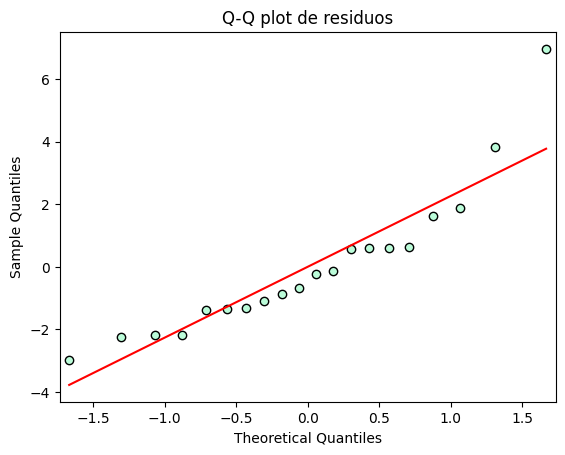

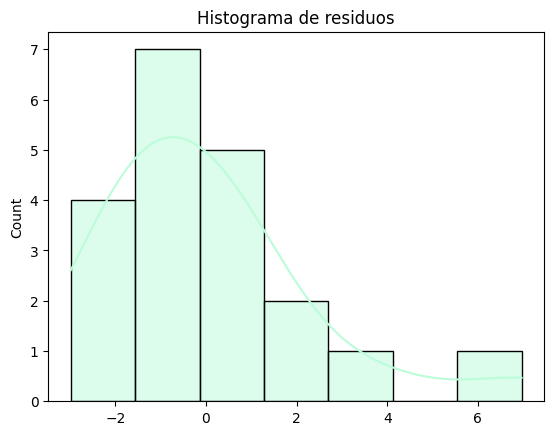

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s',
          markerfacecolor='#BBFCD9',markeredgecolor='black',)
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True,color="#BBFCD9")
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['Tratamiento'] == 'Con_Tratamiento']['Porcentaje_de_cometas']
grupo_B = df[df['Tratamiento'] == 'Sin_Tratamiento']['Porcentaje_de_cometas']

stat, p = levene(grupo_A, grupo_B)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 1.1180
p-valor: 0.3043


Lambda óptimo: 0.32061169162391906


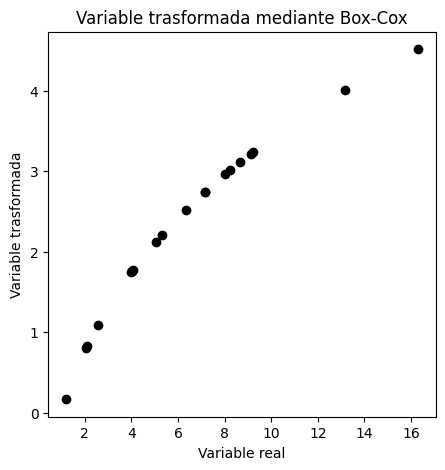

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["Porcentaje_de_cometas_boxcox"], lambda_opt = boxcox(df["Porcentaje_de_cometas"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["Porcentaje_de_cometas"], df["Porcentaje_de_cometas_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [ ]:
# Marielena Carvajal Becerra
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('Porcentaje_de_cometas_boxcox ~ C(Tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tratamiento),15.8598,1.0,38.9108,0.0
Residual,7.3367,18.0,NaN,NaN


In [ ]:
residuales = modelo.resid
# Marielena Carvajal Becerra

valor-p (Shapiro) = 0.9455348310737177


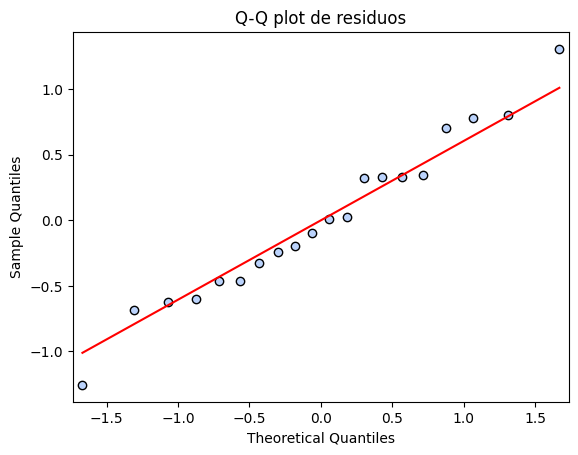

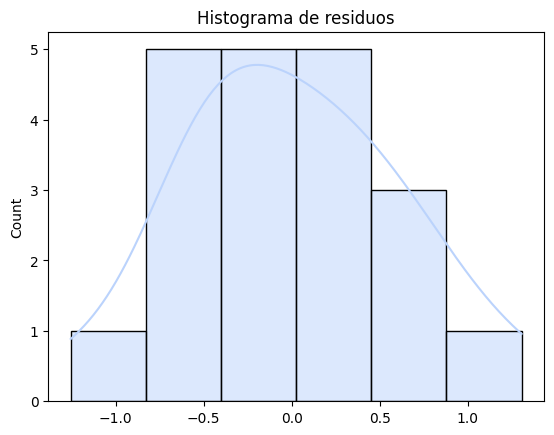

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s',
          markerfacecolor='#BBD3FC',markeredgecolor='black',)
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True,color="#BBD3FC")
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Marielena Carvajal Becerra
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['Tratamiento'] == 'Con_Tratamiento']['Porcentaje_de_cometas_boxcox']
grupo_B = df[df['Tratamiento'] == 'Sin_Tratamiento']['Porcentaje_de_cometas_boxcox']

stat, p = levene(grupo_A, grupo_B)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.1523
p-valor: 0.7009


        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
     group1          group2     meandiff p-adj lower  upper  reject
-------------------------------------------------------------------
Con_Tratamiento Sin_Tratamiento    1.781   0.0 1.1812 2.3808   True
-------------------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

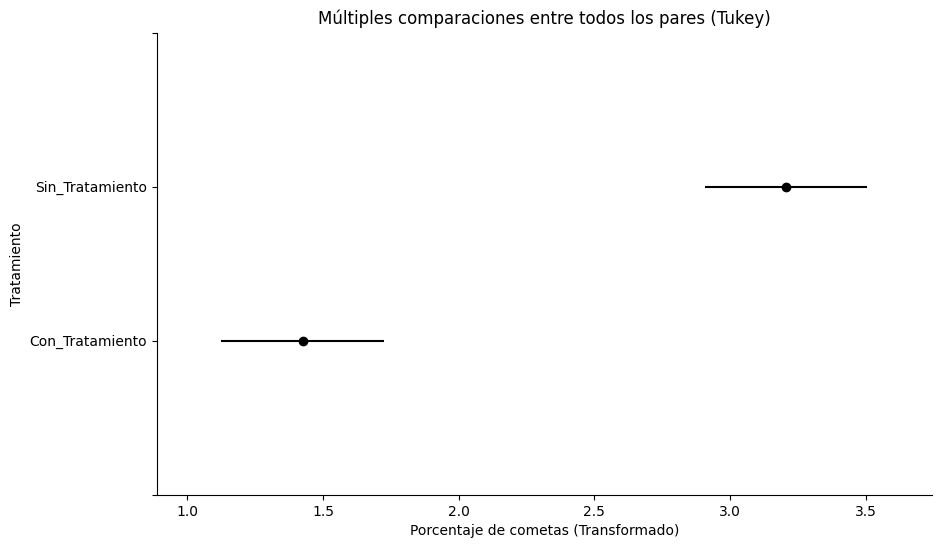

In [ ]:
# Marielena Carvajal Becerra
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Porcentaje_de_cometas_boxcox'], # Variable de respuesta
    groups=df['Tratamiento'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Tratamiento", xlabel="Porcentaje de cometas (Transformado)")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

Conclusión:

Al principio los datos no cumplían con la normalidad, porque la prueba de Shapiro dio un valor de 0.0132. Por esta razón se aplicó una transformación Box-Cox. Después de realizarla, se cumplió la normalidad con un valor de 0.9455 y la igualdad de varianzas con 0.7009.

Los resultados mostraron que sí existe una diferencia significativa entre los discos con tratamiento y sin tratamiento. Los discos que recibieron el tratamiento tuvieron un promedio de 3.434 % de cometas. En cambio, los discos sin tratamiento presentaron un promedio de 9.335 %.

Por lo tanto, se recomienda utilizar el tratamiento de limpieza porque reduce el porcentaje de discos con cometas. La transformación Box-Cox ayudó a corregir el problema de normalidad y permitió obtener resultados más confiables.